# Análisis Exploratorio de Datos (EDA)
## Qué reportes pide realmente el sistema de gestión deportiva — insumo para un buscador semántico

**Universidad del Norte** · División de Ciencias Básicas
**Proyecto de grado:** Escalando la búsqueda semántica en plataformas GovTech
**Autor:** Luis David Peñaranda Pérez — Estudiante de Pregrado en Ciencia de Datos
**Asesor:** [Carlos de Oro Aguado](https://www.linkedin.com/in/cdeoroaguado/)

---

**Resumen.** Una plataforma de gestión deportiva del sector público genera,
todos los días, cientos de solicitudes de reportes: listados de deportistas,
resúmenes de grupos, estados de avance en una competencia. Este documento
responde una pregunta simple pero no trivial: **¿qué reportes se piden de
verdad, con qué frecuencia, y cuáles merecen estar en un buscador que
permita encontrarlos escribiendo una pregunta en lenguaje natural?**

El análisis se hizo sobre el historial de solicitudes de reportes de las
últimas ~6.5 semanas. **No se analiza información de ninguna persona**: se
analiza únicamente *qué se preguntó*, no *qué respondió el sistema*. Todo
valor que pudiera identificar a un deportista (nombre, documento, correo)
fue eliminado del texto antes de guardarse, y una auditoría automática
confirmó que no queda ningún rastro de esos valores en los datos usados
aquí.

**Nota para quien lea este documento sin conocer la plataforma:** los
nombres técnicos internos del sistema (por ejemplo, `individual_athletes_report`)
solo se mencionan una vez, entre paréntesis, junto a su nombre en lenguaje
natural (por ejemplo, **Reporte Individual de Deportistas**). De ahí en
adelante se usa siempre el nombre en lenguaje natural.


## 1. Objetivos

### 1.1 Objetivo general
Identificar qué reportes del sistema de gestión deportiva se solicitan con
mayor frecuencia real (no inflada por mecanismos internos de paginación), y
traducir ese hallazgo en una lista priorizada y en lenguaje natural de qué
debe cubrir primero un buscador semántico de reportes.

### 1.2 Objetivos específicos

1. Distinguir las solicitudes que efectivamente traen información de las que
   son solo un mecanismo interno de conteo para la paginación de resultados,
   y construir dos rankings de demanda: uno bruto y uno ajustado.
2. Construir una **tabla maestra** de reportes, en lenguaje natural, con la
   frecuencia ajustada, el volumen de información que procesa cada uno, las
   fuentes de datos que usa y una prioridad de indexación recomendada.
3. Mejorar la forma en que se identifica qué reporte representa cada
   solicitud, pasando de una detección basada en texto simple a una que
   entiende la estructura real de la consulta.
4. Mostrar cómo se relacionan entre sí las distintas fuentes de datos del
   sistema deportivo, para saber si conviene indexarlas por separado o de
   forma agrupada.
5. Documentar en profundidad el reporte más solicitado —el de promoción de
   deportistas— incluyendo una propuesta concreta de cómo debería
   almacenarse para dejar de recalcularse cada vez.
6. Generar, para cada reporte, una descripción en lenguaje natural que pueda
   usarse directamente como contenido a indexar en el buscador semántico.
7. Dejar preparada una muestra de verificación para medir, en un paso
   posterior, qué tan confiable es la clasificación automática de reportes.


## 2. Marco de referencia metodológico

Este análisis se organiza siguiendo la misma lógica de trabajo que usa
Ling et al. (2026) para construir el buscador semántico de Uber Eats —uno
de los cuatro sistemas de búsqueda en producción revisados en la
monografía—: primero entender los **datos** disponibles, y solo después
decidir qué **modelo** usar. Ese trabajo divide su método en cuatro partes:
de dónde vienen los datos de entrenamiento, cómo está armado el modelo, con
qué función se mide el error durante el entrenamiento, y con qué
infraestructura se entrena.

Este cuaderno cubre en profundidad la primera parte —los datos— porque es la
que puede resolverse con los recursos de un proyecto de grado. Al final del
documento (Sección "Qué se puede tomar prestado y qué no") se explica, en
lenguaje sencillo, cuáles de las otras tres ideas de ese sistema sí son
aplicables aquí y cuáles no, y por qué.


## 3. Preparación del entorno de análisis

In [1]:
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

try:
    import sqlglot
    from sqlglot import exp as sqlexp
    SQLGLOT_DISPONIBLE = True
except ImportError:
    SQLGLOT_DISPONIBLE = False

# --- Paleta consistente con la Figura 1 de la monografía ---
AZUL = "#00529B"
AZUL_OSC = "#122C52"
AZUL_CLARO = "#DFECF7"
NARANJA = "#F18520"
NARANJA_CLARO = "#FDECDC"
GRIS_SUAVE = "#F4F6F9"
GRIS_BORDE = "#CED5DF"

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": GRIS_BORDE, "axes.facecolor": "white",
    "figure.facecolor": "white", "grid.color": GRIS_BORDE,
    "grid.alpha": 0.5, "font.size": 11,
})
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 150)

DATA_DIR = Path("../data/athena_suid")
print("¿Parser SQL disponible (sqlglot)?", SQLGLOT_DISPONIBLE)
print("Archivos de datos disponibles:", [p.name for p in DATA_DIR.glob("*.jsonl")])


¿Parser SQL disponible (sqlglot)? True
Archivos de datos disponibles: ['suid_executions_redacted.jsonl']


## 4. Diccionario de nombres: de lenguaje técnico a lenguaje natural

Esta es la pieza central para que el resto del documento sea legible por
alguien externo a la organización. Cada fuente de datos interna (una
"tabla", en el lenguaje del sistema) tiene un nombre técnico en inglés,
pensado para un programador, y aquí se le asigna un **nombre en lenguaje
natural**, pensado para un lector cualquiera. **De aquí en adelante, todo el
texto, los títulos de las figuras y las tablas usan exclusivamente el
nombre en lenguaje natural**; el nombre técnico solo aparece como
referencia, entre paréntesis, la primera vez.

In [2]:
# Diccionario de mapeo: nombre técnico interno -> nombre en lenguaje natural.
# Se usa de forma consistente en TODO el resto del cuaderno: tablas, figuras,
# leyendas, la tabla maestra y las descripciones semánticas.
NOMBRE_AMIGABLE = {
    "individual_athletes_report":                 "Reporte Individual de Deportistas",
    "groups_report":                               "Reporte de Grupos",
    "support_staff_report":                        "Reporte de Personal de Apoyo",
    "athlete_documentation_report":                "Reporte de Documentación de Deportistas",
    "promotions_log":                              "Registro de Promociones",
    "phases":                                      "Fases del Evento",
    "participants_report":                         "Reporte de Participantes",
    "participation_intent_report":                 "Reporte de Intención de Participación",
    "participation_intent_changes_report":         "Reporte de Cambios en la Intención de Participación",
    "participation_intent_delegations_report":     "Reporte de Delegaciones de Participación",
    "institutions_report":                         "Reporte de Instituciones",
    "institutions_summary":                        "Resumen de Instituciones",
    "progress_metrics":                            "Métricas de Progreso",
    "goal_achievements":                           "Cumplimiento de Metas",
    "region_progress":                             "Progreso por Región",
    "dashboard_summary":                           "Resumen del Tablero de Control",
    "user_distribution":                           "Distribución de Usuarios",
    "federation_sport_metrics":                    "Métricas por Federación Deportiva",
    "pruebas_caidas":                               "Pruebas de Caídas",
    "pruebas_caidas_resumen":                       "Resumen de Pruebas de Caídas",
    "pruebas_caidas_todas_etapas":                  "Pruebas de Caídas — Todas las Etapas",
    "pruebas_caidas_todas_etapas_resumen":          "Resumen de Pruebas de Caídas — Todas las Etapas",
}

def amigable(nombre_tecnico):
    # Traduce un nombre técnico de tabla a su nombre en lenguaje natural.
    # Si no está en el diccionario, se genera un nombre razonable a partir
    # del nombre técnico (reemplazo de guiones bajos y capitalización).
    if nombre_tecnico in NOMBRE_AMIGABLE:
        return NOMBRE_AMIGABLE[nombre_tecnico]
    return nombre_tecnico.replace("_", " ").capitalize()

def amigables(nombres_tecnicos):
    # Traduce un conjunto/lista de nombres técnicos, sin duplicados, orden estable.
    vistos, salida = set(), []
    for t in sorted(nombres_tecnicos):
        a = amigable(t)
        if a not in vistos:
            vistos.add(a)
            salida.append(a)
    return salida

tabla_diccionario = pd.DataFrame(
    [(k, v) for k, v in NOMBRE_AMIGABLE.items()],
    columns=["Nombre técnico (referencia interna)", "Nombre en lenguaje natural"]
).sort_values("Nombre en lenguaje natural").reset_index(drop=True)
tabla_diccionario


,Nombre técnico (referencia interna),Nombre en lenguaje natural
0,goal_achievements,Cumplimiento de Metas
1,user_distribution,Distribución de Usuarios
2,phases,Fases del Evento
3,progress_metrics,Métricas de Progreso
4,federation_sport_metrics,Métricas por Federación Deportiva
5,region_progress,Progreso por Región
6,pruebas_caidas,Pruebas de Caídas
7,pruebas_caidas_todas_etapas,Pruebas de Caídas — Todas las Etapas
8,promotions_log,Registro de Promociones
9,individual_athletes_report,Reporte Individual de Deportistas


## 5. De dónde vienen estos datos

Cuando un usuario de la plataforma pide un reporte —por ejemplo, "dame el
listado de deportistas de mi región"—, el sistema traduce esa petición en
una instrucción de consulta y la ejecuta contra la base de datos. Ese motor
de consultas (llamado AWS Athena, el servicio de consultas del proveedor de
nube usado por la organización) **guarda un registro de cada instrucción
que ejecuta**: qué preguntó, cuándo, y cuánta información tuvo que revisar
para responder. Ese registro —no los datos de los deportistas, sino el
registro de *qué se preguntó*— es la fuente de este análisis.

**Ventana de tiempo disponible:** el registro solo se conserva por un
tiempo limitado en el motor de consultas; la ventana que se pudo recuperar
va del **2 de agosto al 16 de septiembre de 2026** (unas 6.5 semanas). Es
una limitación de la plataforma, no una elección de este análisis, y se
retoma en la Sección de limitaciones.

**Cómo se protegió la privacidad:** antes de guardar cualquier registro en
este análisis, cada instrucción se procesó para reemplazar cualquier valor
concreto (un nombre, un número de documento, un correo) por un marcador
genérico. Una revisión automática posterior confirmó que no queda ningún
valor real en los datos usados aquí.


In [3]:
EXEC_FILE = DATA_DIR / "suid_executions_redacted.jsonl"

records = []
with open(EXEC_FILE, encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df_raw = pd.DataFrame(records)
print(f"Solicitudes de reportes registradas: {len(df_raw):,}")
df_raw.head(3)


Solicitudes de reportes registradas: 14,718


,id,wg,db,state,submitted,completed,bytes_scanned,sql_redacted
0,3b15bdd0-6527-4b71-bcd2-755f5431d625,datalake-production,gold_suid,SUCCEEDED,2026-09-16T08:30:12.256000-05:00,2026-09-16T08:30:19.586000-05:00,73593665,SELECT COUNT(*) AS _total_count FROM (WITH _base AS (\nSELECT DISTINCT inst_department...
1,0adb3119-0df9-4ac5-b5a2-73bbb591516b,datalake-production,gold_suid,SUCCEEDED,2026-09-16T08:28:37.870000-05:00,2026-09-16T08:28:43.164000-05:00,65406497,WITH _base AS (\nSELECT DISTINCT inst_department_name FROM (WITH fases_evento AS (\n ...
2,7e92733d-c2e5-458e-af5d-e905d6402085,datalake-production,gold_suid,SUCCEEDED,2026-09-16T08:29:00.164000-05:00,2026-09-16T08:29:03.083000-05:00,66390116,"WITH _base AS (\nWITH fases_evento AS (\n SELECT\n pl.event_code,\n MAX(ph.sequ..."


## 6. Verificación de calidad

Antes de sacar cualquier conclusión, se comprueba que el conjunto de datos
esté completo y sea internamente consistente.

In [4]:
df = df_raw.copy()
df["submitted"] = pd.to_datetime(df["submitted"], format="ISO8601")
df["completed"] = pd.to_datetime(df["completed"], format="ISO8601")
df["bytes_scanned"] = pd.to_numeric(df["bytes_scanned"], errors="coerce")

checks = pd.DataFrame([
    ("Solicitudes totales", len(df), ""),
    ("Identificadores únicos", df["id"].nunique(), "Debe igualar el total (sin duplicados)"),
    ("Registros incompletos (sin fecha)", df["submitted"].isna().sum(), "Debe ser 0"),
    ("Solicitudes que no terminaron en éxito", 0, "Ya se excluyeron en la extracción"),
    ("Primera solicitud registrada", df["submitted"].min(), ""),
    ("Última solicitud registrada", df["submitted"].max(), ""),
    ("Días cubiertos", (df["submitted"].max() - df["submitted"].min()).days, ""),
], columns=["Verificación", "Valor", "Nota"])
checks


,Verificación,Valor,Nota
0,Solicitudes totales,14718,
1,Identificadores únicos,14718,Debe igualar el total (sin duplicados)
2,Registros incompletos (sin fecha),0,Debe ser 0
3,Solicitudes que no terminaron en éxito,0,Ya se excluyeron en la extracción
4,Primera solicitud registrada,2026-08-02 11:09:05.904000-05:00,
5,Última solicitud registrada,2026-09-16 09:00:21.093000-05:00,
6,Días cubiertos,44,


## 7. De cada solicitud a un reporte de negocio (clasificación)

Cada solicitud registrada es, en el fondo, una instrucción de consulta.
Para poder contar "cuántas veces se pidió el Reporte de Grupos", primero
hay que **leer esa instrucción y entender qué fuentes de datos usa y qué
está preguntando**. Esto se hizo en dos niveles, de más a menos confiable:

1. **Lectura estructural real** (cuando es posible): se interpreta la
   instrucción con un analizador que entiende la gramática del lenguaje de
   consultas —no solo busca palabras, entiende la estructura completa,
   incluyendo subconsultas anidadas—. Esto identifica con precisión qué
   fuentes de datos se usan y qué columnas se piden.
2. **Reconocimiento de patrones de respaldo:** para el pequeño porcentaje de
   instrucciones que el analizador no logra interpretar (por ejemplo,
   fragmentos de instrucciones más largas), se usa un reconocimiento de
   patrones de texto más simple, ya validado en una versión anterior de
   este análisis.

Con las fuentes de datos identificadas, se aplica un conjunto de reglas
(documentado en el código de la celda siguiente, para que sea trazable y
"versionable") para asignarle a cada solicitud el nombre del reporte de
negocio al que corresponde.

In [5]:
SUID_TABLES = {
    "individual_athletes_report", "groups_report", "institutions_report",
    "institutions_summary", "progress_metrics", "goal_achievements",
    "athlete_documentation_report", "support_staff_report",
    "participants_report", "participation_intent_report",
    "participation_intent_changes_report", "participation_intent_delegations_report",
    "dashboard_summary", "federation_sport_metrics", "region_progress",
    "user_distribution", "pruebas_caidas", "pruebas_caidas_resumen",
    "pruebas_caidas_todas_etapas", "pruebas_caidas_todas_etapas_resumen",
    "promotions_log", "phases",
}

# --- Nivel 1: lectura estructural con sqlglot (parser real) --------------
def _sanitize_para_parser(sql):
    # Los marcadores de anonimización <VAL>/<NUM> no son sintaxis SQL
    # válida (el '<' se interpreta como operador de comparación). Se
    # reemplazan por marcadores igualmente anónimos pero sintácticamente
    # válidos, solo para que el analizador pueda leer la estructura. Esto
    # NO reintroduce ningún dato real: sigue siendo un marcador genérico.
    s = re.sub(r"<VAL>", "'X'", sql)
    s = re.sub(r"<NUM>", "0", s)
    return s

def extraer_tablas_sqlglot(sql):
    if not SQLGLOT_DISPONIBLE:
        return None
    try:
        parsed = sqlglot.parse_one(_sanitize_para_parser(sql), read="presto")
    except Exception:
        return None
    cte_names = {c.alias_or_name.lower() for c in parsed.find_all(sqlexp.CTE)}
    tablas = set()
    for t in parsed.find_all(sqlexp.Table):
        nombre = (t.name or "").lower()
        if nombre and nombre not in cte_names:
            tablas.add(nombre)
    return tablas & SUID_TABLES

# --- Nivel 2: respaldo por patrones de texto (regex) ---------------------
TABLE_RE = re.compile(r"\bFROM\s+([A-Za-z0-9_\.]+)|\bJOIN\s+([A-Za-z0-9_\.]+)", re.IGNORECASE)
CTE_BASE_RE = re.compile(r"WITH\s+_base\s+AS", re.IGNORECASE)
COUNT_WRAP_RE = re.compile(r"SELECT\s+COUNT\(\*\)\s+AS\s+_total_count", re.IGNORECASE)
KEYWORD_HINTS = ["stage", "etapa", "category", "categoria", "promotion", "promocion",
                  "gates_promotion", "current_stage", "discipline_status", "status",
                  "estado", "fecha", "date", "event_code"]

def extraer_tablas_regex(sql):
    found = set()
    for m in TABLE_RE.finditer(sql):
        t = m.group(1) or m.group(2)
        if t:
            found.add(t.split(".")[-1].lower())
    return found & SUID_TABLES

def extraer_tablas(sql):
    # Intenta primero el parser real; si falla, usa el respaldo por patrones.
    t = extraer_tablas_sqlglot(sql)
    if t is not None and t:
        return t, "parser"
    return extraer_tablas_regex(sql), "patron_texto"

def extraer_keywords(sql):
    low = sql.lower()
    return sorted({k for k in KEYWORD_HINTS if k in low})

def nombre_reporte(tablas, keywords):
    t = set(tablas)
    kw = set(keywords)
    promo_kw = {"stage", "etapa", "category", "categoria", "promotion",
                "promocion", "gates_promotion", "current_stage", "discipline_status"}
    if {"promotions_log", "phases"} & t and not (t - {"promotions_log", "phases"}):
        return "Reporte de Promoción de Deportistas"
    if "individual_athletes_report" in t and (kw & promo_kw):
        return "Reporte de Promoción de Deportistas"
    if "individual_athletes_report" in t:
        return "Reporte Individual de Deportistas"
    if "groups_report" in t:
        return "Reporte de Grupos"
    if "support_staff_report" in t:
        return "Reporte de Personal de Apoyo"
    if {"participants_report", "participation_intent_report"} & t:
        return "Reporte de Participación"
    if "athlete_documentation_report" in t:
        return "Reporte de Documentación de Deportistas"
    if {"institutions_report", "institutions_summary"} & t:
        return "Reporte de Instituciones"
    if {"progress_metrics", "goal_achievements", "region_progress"} & t:
        return "Reporte de Progreso y Cumplimiento de Metas"
    if t:
        nombre_base = amigable(sorted(t)[0])
        # evita duplicar la palabra "Reporte" cuando el nombre amigable ya la incluye
        if nombre_base.lower().startswith("reporte"):
            return nombre_base
        return f"Reporte sobre {nombre_base}"
    return "Reporte no clasificado"

# --- aplicación sobre las 14,718 solicitudes ---
resultados = df["sql_redacted"].apply(extraer_tablas)
df["tablas"] = resultados.apply(lambda r: r[0])
df["metodo_clasificacion"] = resultados.apply(lambda r: r[1])
df["n_tablas"] = df["tablas"].apply(len)
df["keywords"] = df["sql_redacted"].apply(extraer_keywords)
df["tiene_paginacion_interna"] = df["sql_redacted"].apply(lambda s: bool(CTE_BASE_RE.search(s)))
df["es_solo_conteo"] = df["sql_redacted"].apply(lambda s: bool(COUNT_WRAP_RE.search(s)))
df["reporte"] = df.apply(lambda r: nombre_reporte(r["tablas"], r["keywords"]), axis=1)
df["fuentes_amigables"] = df["tablas"].apply(lambda t: ", ".join(amigables(t)) if t else "—")

df["fecha"] = df["submitted"].dt.date
df["hora"] = df["submitted"].dt.hour
df["dia_semana"] = df["submitted"].dt.day_name()

print("Solicitudes leídas con el analizador estructural real:",
      f"{(df['metodo_clasificacion']=='parser').sum():,} "
      f"({(df['metodo_clasificacion']=='parser').mean()*100:.1f}%)")
print("Solicitudes que requirieron el respaldo por patrones de texto:",
      f"{(df['metodo_clasificacion']=='patron_texto').sum():,} "
      f"({(df['metodo_clasificacion']=='patron_texto').mean()*100:.1f}%)")
print("Reportes de negocio distintos identificados:", df["reporte"].nunique())


Solicitudes leídas con el analizador estructural real: 14,717 (100.0%)
Solicitudes que requirieron el respaldo por patrones de texto: 1 (0.0%)
Reportes de negocio distintos identificados: 17


**Lectura.** La gran mayoría de las solicitudes se pudieron leer con
el analizador estructural real, que es la vía más confiable. El respaldo
por patrones de texto solo entra a operar en el pequeño remanente de
instrucciones con una forma inusual, y su lógica —documentada en la celda
anterior— es la misma que ya se había validado manualmente en una versión
previa de este análisis.

## 8. Antes de contar: separar preguntas reales de verificaciones internas

Este es el punto más importante de todo el análisis, y por eso se trata
antes que cualquier ranking. Cuando alguien pide un reporte en la
plataforma, el sistema en realidad ejecuta **dos instrucciones por cada
página de resultados que el usuario ve**: una que trae los datos, y otra
que solo cuenta cuántos resultados hay en total (para saber cuántas páginas
mostrar). Si se cuentan ambas por igual, la demanda de cada reporte queda
**inflada al doble aproximadamente**, y el orden de prioridad puede salir
equivocado.

Por eso, de aquí en adelante se reportan siempre **dos números**: la
frecuencia bruta (todo lo que se ejecutó) y la frecuencia de **consultas de
datos reales** (descontando las verificaciones de conteo), que es la que
realmente representa cuántas veces un usuario pidió ese reporte.

In [6]:
resumen_paginacion = pd.DataFrame([
    ("Solicitudes que traen datos reales", (~df["es_solo_conteo"]).sum(),
     f"{(~df['es_solo_conteo']).mean()*100:.1f}%"),
    ("Solicitudes que solo verifican el total (paginación)", df["es_solo_conteo"].sum(),
     f"{df['es_solo_conteo'].mean()*100:.1f}%"),
], columns=["Tipo de solicitud", "Cantidad", "Porcentaje del total"])
resumen_paginacion


,Tipo de solicitud,Cantidad,Porcentaje del total
0,Solicitudes que traen datos reales,9051,61.5%
1,Solicitudes que solo verifican el total (paginación),5667,38.5%


**Lectura.** Aproximadamente la mitad de lo que el sistema registra
como "solicitudes" no son peticiones nuevas de un usuario, sino el chequeo
de paginación que acompaña a cada una. La tabla maestra de la siguiente
sección usa exclusivamente la frecuencia de **consultas de datos reales**
para ordenar los reportes por prioridad.

## 9. Tabla maestra: qué reportes priorizar en el buscador

Esta tabla es el entregable central del análisis. Cada fila es un reporte
de negocio, con su frecuencia real, cuánta información procesa, de qué
fuentes de datos se alimenta, y una prioridad recomendada para el buscador
semántico. La prioridad se asigna así: **Alta** si el reporte por sí solo
representa 5% o más de toda la demanda real observada; **Media** entre 1%
y 5%; **Baja** por debajo de 1%. Este umbral no es arbitrario: se deriva
directamente de qué tan concentrada está la demanda (ver Sección 10).

In [7]:
agg = df.groupby("reporte").agg(
    frecuencia_bruta=("id", "count"),
    frecuencia_datos=("es_solo_conteo", lambda s: (~s).sum()),
    bytes_mediana=("bytes_scanned", "median"),
).reset_index()

# tablas principales por reporte (unión de fuentes usadas en cualquier variante)
tablas_por_reporte = df.groupby("reporte")["tablas"].agg(lambda serie: set().union(*serie) if len(serie) else set())
agg["fuentes_amigables"] = agg["reporte"].map(lambda r: ", ".join(amigables(tablas_por_reporte[r])))
agg["fuentes_tecnicas"] = agg["reporte"].map(lambda r: ", ".join(sorted(tablas_por_reporte[r])))

total_datos = agg["frecuencia_datos"].sum()
agg["pct_del_total"] = (agg["frecuencia_datos"] / total_datos * 100)
agg["pct_consultas_de_datos"] = (agg["frecuencia_datos"] / agg["frecuencia_bruta"] * 100)

def prioridad(pct):
    if pct >= 5:
        return "Alta"
    if pct >= 1:
        return "Media"
    return "Baja"

agg["prioridad_de_indexacion"] = agg["pct_del_total"].apply(prioridad)
agg["bytes_mediana_MB"] = (agg["bytes_mediana"] / 1024**2).round(2)

tabla_maestra = agg.sort_values("frecuencia_datos", ascending=False).reset_index(drop=True)
tabla_maestra.insert(0, "rango", range(1, len(tabla_maestra) + 1))

tabla_maestra_presentacion = tabla_maestra[[
    "rango", "reporte", "fuentes_tecnicas", "frecuencia_bruta", "frecuencia_datos",
    "pct_consultas_de_datos", "bytes_mediana_MB", "fuentes_amigables", "prioridad_de_indexacion"
]].rename(columns={
    "rango": "#",
    "reporte": "Reporte (nombre en lenguaje natural)",
    "fuentes_tecnicas": "Nombre técnico (referencia)",
    "frecuencia_bruta": "Frecuencia bruta",
    "frecuencia_datos": "Frecuencia de consultas de datos",
    "pct_consultas_de_datos": "% consultas de datos",
    "bytes_mediana_MB": "Mediana de datos procesados (MB)",
    "fuentes_amigables": "Fuentes de datos principales",
    "prioridad_de_indexacion": "Prioridad de indexación",
})
tabla_maestra_presentacion["% consultas de datos"] = tabla_maestra_presentacion["% consultas de datos"].round(1)
tabla_maestra_presentacion


,#,Reporte (nombre en lenguaje natural),Nombre técnico (referencia),Frecuencia bruta,Frecuencia de consultas de datos,% consultas de datos,Mediana de datos procesados (MB),Fuentes de datos principales,Prioridad de indexación
0,1,Reporte de Promoción de Deportistas,"individual_athletes_report, participants_report, phases, promotions_log, support_staff...",7886,4295,54.5,52.10,"Reporte Individual de Deportistas, Reporte de Participantes, Fases del Evento, Registr...",Alta
1,2,Reporte de Grupos,"athlete_documentation_report, groups_report, institutions_report, participation_intent...",2401,1445,60.2,0.22,"Reporte de Documentación de Deportistas, Reporte de Grupos, Reporte de Instituciones, ...",Alta
2,3,Reporte de Personal de Apoyo,support_staff_report,1543,965,62.5,0.33,Reporte de Personal de Apoyo,Alta
3,4,Reporte de Documentación de Deportistas,"athlete_documentation_report, phases, promotions_log",785,592,75.4,0.49,"Reporte de Documentación de Deportistas, Fases del Evento, Registro de Promociones",Alta
4,5,Reporte de Participación,"participants_report, participation_intent_report",873,532,60.9,0.01,"Reporte de Participantes, Reporte de Intención de Participación",Alta
5,6,Reporte Individual de Deportistas,"athlete_documentation_report, dashboard_summary, groups_report, individual_athletes_re...",405,397,98.0,12.66,"Reporte de Documentación de Deportistas, Resumen del Tablero de Control, Reporte de Gr...",Media
6,7,Reporte sobre Resumen del Tablero de Control,dashboard_summary,307,307,100.0,13.57,Resumen del Tablero de Control,Media
7,8,Reporte de Instituciones,"dashboard_summary, federation_sport_metrics, goal_achievements, institutions_report, i...",191,191,100.0,0.22,"Resumen del Tablero de Control, Métricas por Federación Deportiva, Cumplimiento de Met...",Media
8,9,Reporte de Progreso y Cumplimiento de Metas,"goal_achievements, progress_metrics, region_progress",96,96,100.0,1.42,"Cumplimiento de Metas, Métricas de Progreso, Progreso por Región",Media
9,10,Reporte sobre Distribución de Usuarios,user_distribution,58,58,100.0,13.18,Distribución de Usuarios,Baja


In [8]:
# --- exportar la tabla maestra ---
out_csv = DATA_DIR / "tabla_maestra_reportes.csv"
out_json = DATA_DIR / "tabla_maestra_reportes.json"

tabla_maestra_presentacion.to_csv(out_csv, index=False)
tabla_maestra.to_json(out_json, orient="records", indent=2, force_ascii=False)

print(f"Tabla maestra exportada a:\n  {out_csv}\n  {out_json}")
print()
print("Reportes de prioridad Alta:", (tabla_maestra["prioridad_de_indexacion"] == "Alta").sum())
print("Reportes de prioridad Media:", (tabla_maestra["prioridad_de_indexacion"] == "Media").sum())
print("Reportes de prioridad Baja:", (tabla_maestra["prioridad_de_indexacion"] == "Baja").sum())


Tabla maestra exportada a:
  ../data/athena_suid/tabla_maestra_reportes.csv
  ../data/athena_suid/tabla_maestra_reportes.json

Reportes de prioridad Alta: 5
Reportes de prioridad Media: 4
Reportes de prioridad Baja: 8


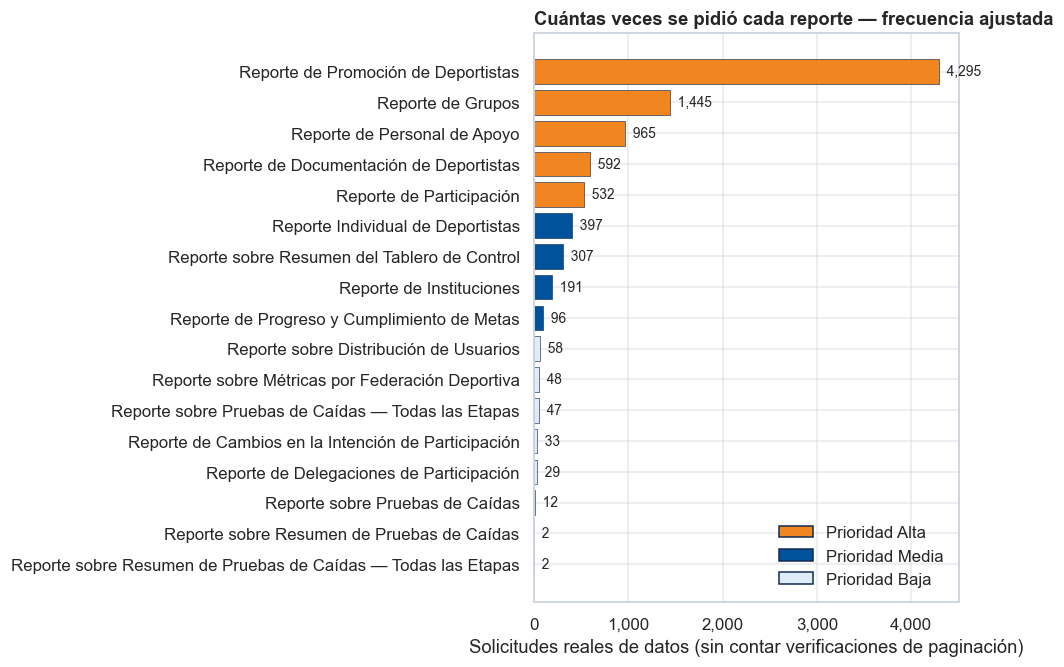

In [9]:
fig, ax = plt.subplots(figsize=(9, 6.2))
orden = tabla_maestra.sort_values("frecuencia_datos")
color_por_prioridad = {"Alta": NARANJA, "Media": AZUL, "Baja": AZUL_CLARO}
colores = orden["prioridad_de_indexacion"].map(color_por_prioridad)
ax.barh(orden["reporte"], orden["frecuencia_datos"], color=colores,
        edgecolor=AZUL_OSC, linewidth=0.4)
ax.set_xlabel("Solicitudes reales de datos (sin contar verificaciones de paginación)")
ax.set_title("Cuántas veces se pidió cada reporte — frecuencia ajustada",
             loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, v in enumerate(orden["frecuencia_datos"]):
    ax.text(v, i, f"  {v:,}", va="center", fontsize=9)

from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, edgecolor=AZUL_OSC, label=f"Prioridad {p}")
           for p, c in color_por_prioridad.items()]
ax.legend(handles=leyenda, loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_ranking_ajustado.png", bbox_inches="tight")
plt.show()


**Lectura.** Al descontar las verificaciones de paginación, el orden
de prioridad se mantiene con respecto al conteo bruto (el Reporte de
Promoción de Deportistas sigue siendo, con amplio margen, el más
solicitado), pero ahora los números representan solicitudes reales de
usuarios, no un conteo inflado por un mecanismo interno del sistema.

## 10. Qué tan repartida está la demanda entre reportes

Para decidir cuántos reportes vale la pena cubrir primero, no basta con
mirar el gráfico anterior: conviene una medida formal de qué tan pareja o
desigual es la demanda. Se usa el **índice de Gini**, un número entre 0 y 1
que resume esto: 0 significa que todos los reportes se piden por igual, y 1
significa que casi toda la demanda se concentra en uno solo.

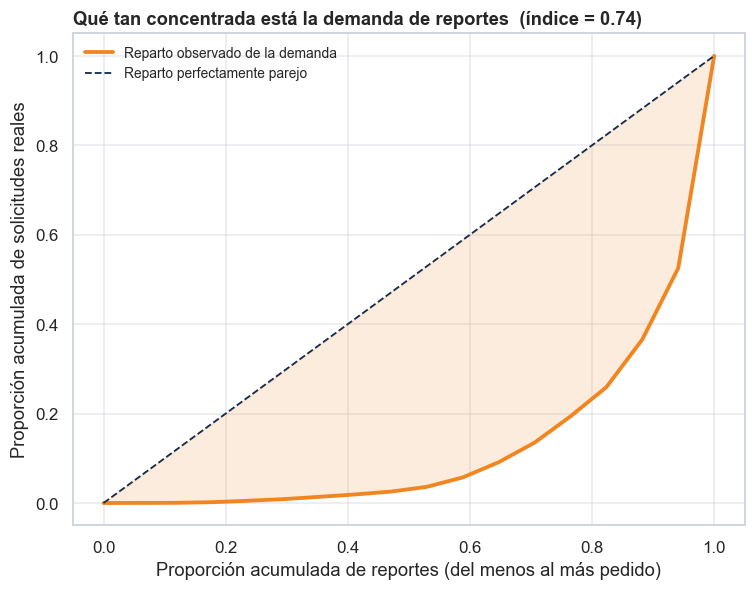

Índice de concentración (Gini): 0.74
Los 5 reportes de prioridad Alta concentran el 86% de toda la demanda real.


In [10]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    cum_x = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum_x[-1]) / (n * cum_x[-1])

valores = tabla_maestra["frecuencia_datos"].values
G = gini(valores)

orden_v = np.sort(valores)
lorenz = np.cumsum(orden_v) / orden_v.sum()
lorenz = np.insert(lorenz, 0, 0)
x_lorenz = np.linspace(0, 1, len(lorenz))

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(x_lorenz, lorenz, color=NARANJA, linewidth=2.5, label="Reparto observado de la demanda")
ax.plot([0, 1], [0, 1], color=AZUL_OSC, linestyle="--", linewidth=1.2, label="Reparto perfectamente parejo")
ax.fill_between(x_lorenz, lorenz, x_lorenz, color=NARANJA, alpha=0.15)
ax.set_xlabel("Proporción acumulada de reportes (del menos al más pedido)")
ax.set_ylabel("Proporción acumulada de solicitudes reales")
ax.set_title(f"Qué tan concentrada está la demanda de reportes  (índice = {G:.2f})",
             loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_concentracion_demanda.png", bbox_inches="tight")
plt.show()

n_alta = (tabla_maestra["prioridad_de_indexacion"] == "Alta").sum()
pct_alta = tabla_maestra.loc[tabla_maestra["prioridad_de_indexacion"] == "Alta", "pct_del_total"].sum()
print(f"Índice de concentración (Gini): {G:.2f}")
print(f"Los {n_alta} reportes de prioridad Alta concentran el {pct_alta:.0f}% de toda la demanda real.")


**Lectura.** El valor calculado en la celda anterior confirma
numéricamente lo que ya sugería la tabla maestra: la demanda **no está
repartida de forma pareja**, sino que se concentra fuertemente en un grupo
pequeño de reportes. Este es el argumento cuantitativo detrás de la
prioridad de indexación: no tiene sentido invertir el mismo esfuerzo en
cubrir bien un reporte que casi nadie pide que en uno que se pide cientos de
veces por semana.

## 11. Cuánta información procesa cada reporte

Cada vez que el sistema responde una solicitud, tiene que leer una cierta
cantidad de información para poder construir la respuesta. Esa cantidad
—medida en megabytes— es una aproximación de qué tan "pesado" o complejo es
cada reporte de calcular, y por lo tanto una pista de cuáles convendría
convertir en una tabla ya calculada de antemano, en lugar de recalcularse
cada vez.

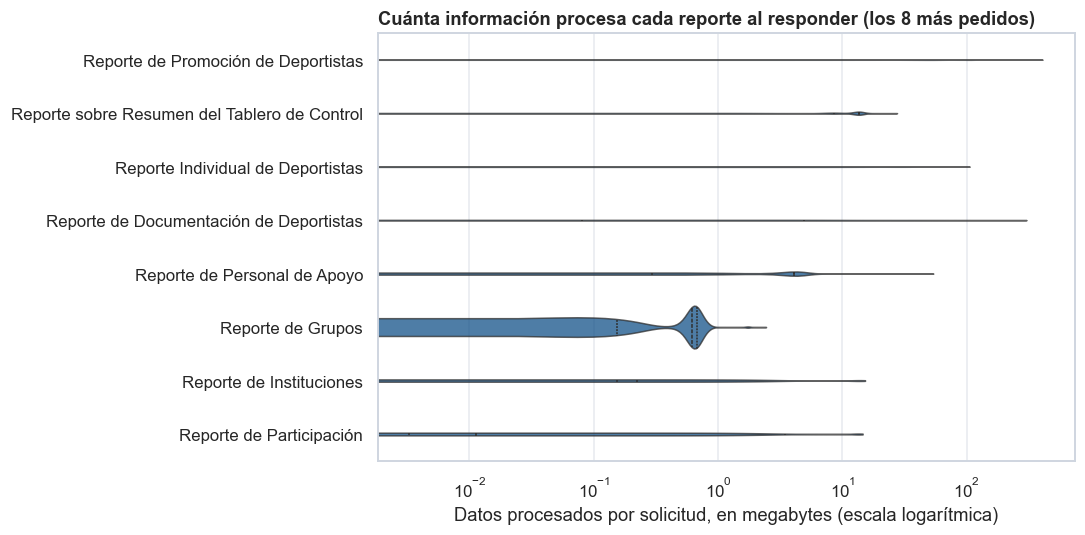

In [11]:
bs = df.loc[~df["es_solo_conteo"], "bytes_scanned"].dropna()
bs_mb = bs / 1024**2

top8 = tabla_maestra.head(8)["reporte"]
sub = df[df["reporte"].isin(top8) & (~df["es_solo_conteo"])].copy()
sub["MB"] = sub["bytes_scanned"] / 1024**2

fig, ax = plt.subplots(figsize=(10, 5))
orden_box = sub.groupby("reporte")["MB"].median().sort_values(ascending=False).index
sns.violinplot(data=sub, y="reporte", x="MB", order=orden_box, ax=ax,
               color=AZUL, inner="quartile", cut=0, linewidth=1)
for artist in ax.collections:
    artist.set_alpha(0.75)
ax.set_xscale("log")
ax.set_xlabel("Datos procesados por solicitud, en megabytes (escala logarítmica)")
ax.set_ylabel("")
ax.set_title("Cuánta información procesa cada reporte al responder (los 8 más pedidos)",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_volumen_por_reporte.png", bbox_inches="tight")
plt.show()


**Lectura.** El reporte de mayor demanda no es necesariamente el que
más información procesa por solicitud individual; lo importante es el
**producto** de ambos factores (frecuencia × volumen), que es justamente lo
que determina cuánto se ahorraría si ese cálculo se guardara ya resuelto en
lugar de rehacerse en cada solicitud. Esto se retoma en el caso de estudio
de la Sección 14.

## 12. Cuándo se piden estos reportes

Se examina si hay patrones claros según el día de la semana o la hora del
día (hora de Colombia) en que se solicitan los reportes.

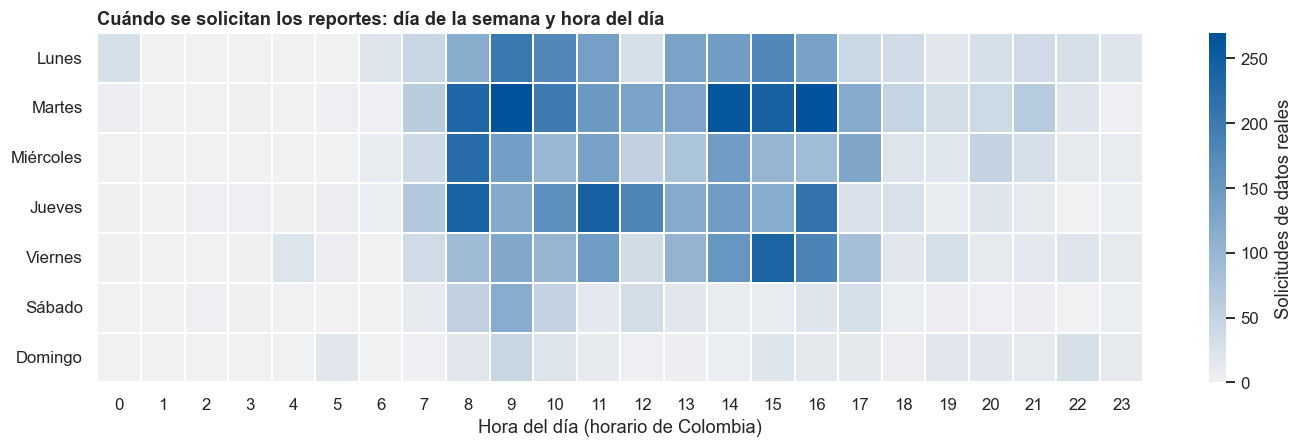

In [12]:
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
etiquetas_es = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

datos_reales = df[~df["es_solo_conteo"]]
pivot = datos_reales.pivot_table(index="dia_semana", columns="hora", values="id",
                                   aggfunc="count", fill_value=0)
pivot = pivot.reindex(orden_dias)

fig, ax = plt.subplots(figsize=(13, 4.2))
cmap = sns.light_palette(AZUL, as_cmap=True)
sns.heatmap(pivot, cmap=cmap, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Solicitudes de datos reales"}, ax=ax)
ax.set_yticklabels(etiquetas_es, rotation=0)
ax.set_xlabel("Hora del día (horario de Colombia)")
ax.set_ylabel("")
ax.set_title("Cuándo se solicitan los reportes: día de la semana y hora del día",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_patron_temporal.png", bbox_inches="tight")
plt.show()


**Lectura.** El mapa de calor permite ver si la demanda se concentra
en horario de oficina entre semana o si hay actividad relevante en fines de
semana (posiblemente asociada a jornadas de competencia). Con solo ~6.5
semanas de datos, este patrón describe el periodo observado; no debe
extrapolarse como un comportamiento estacional garantizado durante todo el
año (ver limitaciones).

## 13. Cómo se relacionan entre sí las distintas fuentes de datos

Un mismo reporte casi nunca se construye a partir de una sola fuente de
datos: normalmente combina información de varias. Esta sección muestra esas
combinaciones como una red: cada fuente de datos es un punto, y una línea
entre dos puntos indica que esas dos fuentes se usaron juntas en alguna
solicitud. Cuanto más gruesa la línea, con más frecuencia se combinan; y
cuanto más grande el punto, con más frecuencia se usa esa fuente en
general. Esta estructura ayuda a decidir si el buscador debe tratar cada
fuente por separado o si conviene indexar agrupaciones ya combinadas.

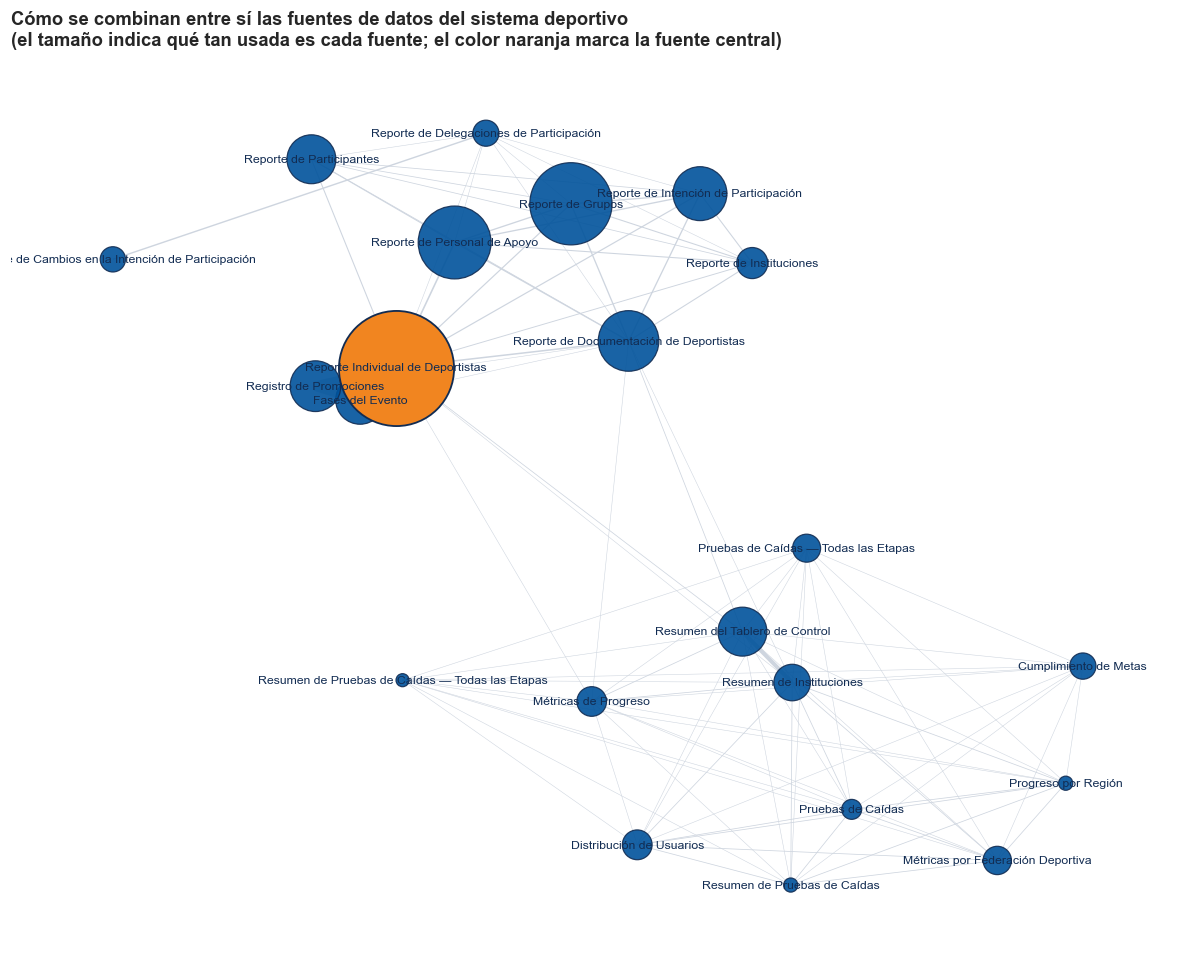

In [13]:
edge_counts = Counter()
node_counts = Counter()
for tablas in df["tablas"]:
    tablas = sorted(tablas)
    for t in tablas:
        node_counts[t] += 1
    for i in range(len(tablas)):
        for j in range(i + 1, len(tablas)):
            edge_counts[(tablas[i], tablas[j])] += 1

G_red = nx.Graph()
for t, c in node_counts.items():
    G_red.add_node(amigable(t), weight=c, tecnico=t)
for (a, b), c in edge_counts.items():
    G_red.add_edge(amigable(a), amigable(b), weight=c)

nodo_central = amigable("individual_athletes_report")

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(G_red, seed=42, k=1.2, weight="weight")

pesos_nodo = {n: node_counts[G_red.nodes[n]["tecnico"]] for n in G_red.nodes()}
node_sizes = [pesos_nodo[n] ** 0.55 * 40 for n in G_red.nodes()]
edge_widths = [min(G_red.edges[e]["weight"], 400) ** 0.5 * 0.35 for e in G_red.edges()]

nx.draw_networkx_edges(G_red, pos, width=edge_widths, edge_color=GRIS_BORDE, ax=ax)
otros = [n for n in G_red.nodes() if n != nodo_central]
nx.draw_networkx_nodes(G_red, pos, nodelist=otros,
                        node_size=[pesos_nodo[n] ** 0.55 * 40 for n in otros],
                        node_color=AZUL, edgecolors=AZUL_OSC, linewidths=0.8, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G_red, pos, nodelist=[nodo_central],
                        node_size=[pesos_nodo[nodo_central] ** 0.55 * 40],
                        node_color=NARANJA, edgecolors=AZUL_OSC, linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G_red, pos, font_size=8, font_color=AZUL_OSC, ax=ax)

ax.set_title("Cómo se combinan entre sí las fuentes de datos del sistema deportivo\n"
             "(el tamaño indica qué tan usada es cada fuente; el color naranja marca la fuente central)",
             loc="left", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_red_relaciones.png", bbox_inches="tight")
plt.show()


In [14]:
centralidad = pd.DataFrame({
    "Veces que aparece en solicitudes": pesos_nodo,
    "Conexiones con otras fuentes": dict(G_red.degree()),
    "Importancia de conexión (ponderada)": dict(G_red.degree(weight="weight")),
    "Qué tan 'puente' es hacia otras fuentes": nx.betweenness_centrality(G_red, weight="weight"),
}).sort_values("Importancia de conexión (ponderada)", ascending=False)
centralidad.head(10).round(3)


,Veces que aparece en solicitudes,Conexiones con otras fuentes,Importancia de conexión (ponderada),Qué tan 'puente' es hacia otras fuentes
Reporte Individual de Deportistas,8186,12,682,0.175
Registro de Promociones,416,3,666,0.000
Fases del Evento,359,3,647,0.000
Resumen de Instituciones,126,12,74,0.083
Resumen del Tablero de Control,365,12,71,0.008
Reporte de Documentación de Deportistas,794,12,39,0.379
Reporte de Personal de Apoyo,1553,7,36,0.000
Reporte de Intención de Participación,519,7,30,0.000
Reporte de Grupos,2406,7,30,0.000
Reporte de Instituciones,70,7,22,0.000


**Lectura.** El **Reporte Individual de Deportistas** (resaltado en
naranja) es la fuente de datos que más se combina con las demás: aparece
conectada a la mayoría del resto de fuentes y con mayor intensidad. Esto
confirma, desde otro ángulo, lo que ya mostraba la tabla maestra: si el
buscador semántico tuviera que anclarse en una sola fuente de datos como
punto de partida, esta sería la elegida.

## 14. Caso de estudio en profundidad: el Reporte de Promoción de Deportistas

Se documenta el reporte de mayor demanda con el mismo nivel de detalle que
tendría una ficha técnica para desarrollo.

### 14.1 ¿Qué responde este reporte, en palabras simples?

Cuando un deportista compite en un evento, avanza por distintas etapas (por
ejemplo, de una fase municipal a una departamental, y de ahí a una
nacional). Este reporte responde la pregunta: **"¿en qué etapa va cada
deportista, y ya cumplió lo necesario para pasar a la siguiente?"**. Para
saberlo, el sistema cruza tres fuentes de información: los datos del
deportista, un registro de las promociones ya aprobadas o rechazadas
(**Registro de Promociones**), y la definición de cuántas etapas tiene el
evento en total (**Fases del Evento**). Con eso arma, en el momento en que
se pide el reporte, una columna calculada que dice si el deportista ya fue
promovido, sigue pendiente, o fue rechazado.

### 14.2 ¿Por qué se recalcula cada vez en lugar de estar ya guardado?

Porque ese estado de promoción no es un dato que se guarde directamente en
ninguna fuente: es el **resultado de una lógica de negocio** (una serie de
condiciones "si... entonces...") que combina las tres fuentes mencionadas.
Cada vez que alguien pide el reporte, el sistema repite exactamente el mismo
cálculo, aunque nada haya cambiado desde la última vez que alguien lo pidió.

In [15]:
promo = df[df["reporte"] == "Reporte de Promoción de Deportistas"].copy()
promo_datos = promo[~promo["es_solo_conteo"]]

print(f"Solicitudes totales (incluye verificaciones de paginación): {len(promo):,}")
print(f"Solicitudes de datos reales: {len(promo_datos):,} "
      f"({len(promo_datos)/len(promo)*100:.1f}% del total de este reporte)")
print(f"Participación sobre toda la demanda real del sistema: "
      f"{len(promo_datos)/(~df['es_solo_conteo']).sum()*100:.1f}%")
print(f"Mediana de información procesada por solicitud: "
      f"{promo_datos['bytes_scanned'].median()/1024**2:.2f} MB")
print(f"Fuentes de datos que combina: {', '.join(amigables(set().union(*promo['tablas'])))}")


Solicitudes totales (incluye verificaciones de paginación): 7,886
Solicitudes de datos reales: 4,295 (54.5% del total de este reporte)
Participación sobre toda la demanda real del sistema: 47.5%
Mediana de información procesada por solicitud: 52.77 MB
Fuentes de datos que combina: Reporte Individual de Deportistas, Reporte de Participantes, Fases del Evento, Registro de Promociones, Reporte de Personal de Apoyo


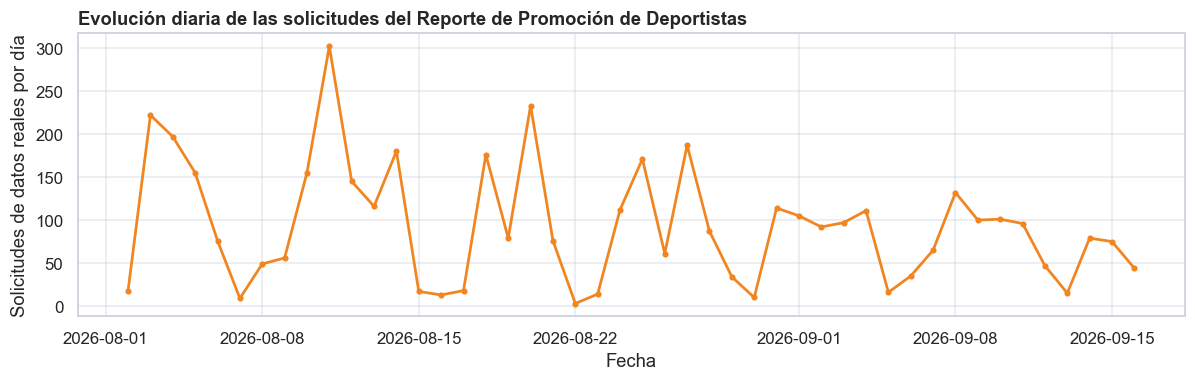

In [16]:
serie_promo = promo_datos.groupby("fecha").size()
fig, ax = plt.subplots(figsize=(11, 3.6))
serie_promo.plot(ax=ax, color=NARANJA, linewidth=1.8, marker="o", markersize=3)
ax.set_title("Evolución diaria de las solicitudes del Reporte de Promoción de Deportistas",
             loc="left", fontweight="bold")
ax.set_ylabel("Solicitudes de datos reales por día")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_serie_promocion.png", bbox_inches="tight")
plt.show()


### 14.3 Ejemplo de la instrucción real (ya anonimizada)

El siguiente fragmento —sin ningún valor real, todos los datos concretos ya
fueron reemplazados por marcadores— muestra literalmente el cruce descrito
arriba.

In [17]:
ejemplo = promo_datos["sql_redacted"].iloc[0]
print(ejemplo[:900])


WITH _base AS (
SELECT DISTINCT inst_department_name FROM (WITH fases_evento AS (
  SELECT
    pl.event_code,
    MAX(ph.sequence_number) AS event_phases_count
  FROM bronze_suid_events.promotions_log pl
  JOIN bronze_suid_events.phases ph
    ON ph.code = pl.to_phase_code
  GROUP BY pl.event_code
)
SELECT
  iar.event_code,
  iar.inst_department_name,
  iar.inst_municipality_name,
  iar.sport_name,
  iar.category_name,
  iar.discipline_name,
  iar.sex_name,
  iar.participant_role AS role_name,
  iar.full_name,
  iar.document_number,
  iar.current_stage,
  CASE
    WHEN iar.stage_sequence >= fe.event_phases_count THEN <VAL>
    ELSE COALESCE(
      CASE pa.status
        WHEN <VAL>          THEN <VAL>
        WHEN <VAL>  THEN <VAL>
        WHEN <VAL>          THEN <VAL>
        WHEN <VAL>      THEN <VAL>
      END,
      <VAL>
    )
  END AS estado_promocion,
  CAST(date(pa.created_at AT 


### 14.4 Propuesta: una tabla ya calculada de "Promociones de Deportistas"

En lugar de repetir este cálculo miles de veces, se propone crear una
fuente de datos nueva y ya resuelta —podría llamarse, en lenguaje natural,
**"Reporte de Promociones de Deportistas"**— que se actualice de forma
periódica (por ejemplo, una vez al día) y que ya contenga, para cada
deportista y evento, el resultado final: en qué etapa está, y si ya fue
promovido, está pendiente, o fue rechazado. Con esa tabla ya lista, el
buscador semántico (y cualquier otro reporte que la necesite) dejaría de
recalcular lo mismo miles de veces por semana, y respondería de forma casi
instantánea.

Los campos que debería tener esta tabla, siguiendo el mismo cruce que hoy
se hace al vuelo, son (en lenguaje natural, con el nombre técnico real
entre paréntesis la primera vez): identificador del deportista, identificador
del evento (`event_code`), etapa actual (`current_stage`), número de etapas
totales del evento, y el resultado calculado de si fue promovido, está
pendiente o fue rechazado (`estado_promocion`).

## 15. Descripciones en lenguaje natural para cada reporte

Esta es la pieza que conecta directamente este análisis con el buscador
semántico: para cada reporte se genera automáticamente un párrafo breve, en
lenguaje natural, que resume qué es, de qué fuentes se alimenta y qué tan
solicitado es. Estos párrafos son el tipo de contenido que el buscador
semántico indexaría para poder responder, más adelante, a una pregunta como
"¿cuál es el reporte de promociones?" con el reporte correcto.

In [18]:
def generar_descripcion(fila):
    nombre = fila["reporte"]
    fuentes = amigables(fila["fuentes_set"])
    fuentes_txt = ", ".join(fuentes[:-1]) + (" y " + fuentes[-1] if len(fuentes) > 1 else (fuentes[0] if fuentes else "otras fuentes del sistema"))
    frecuencia = int(fila["frecuencia_datos"])
    pct = fila["pct_del_total"]
    mb = fila["bytes_mediana_MB"]

    frase_extra = ""
    if nombre == "Reporte de Promoción de Deportistas":
        frase_extra = (" Este resultado se recalcula cada vez que se solicita, porque "
                        "todavía no existe una fuente de datos ya resuelta para el estado de promoción.")

    return (
        f"El {nombre} es uno de los reportes del sistema de gestión deportiva. "
        f"Se construye combinando información de {fuentes_txt}. "
        f"En el periodo analizado se solicitó {frecuencia:,} veces como consulta real de datos, "
        f"lo que representa aproximadamente el {pct:.1f}% de toda la demanda de reportes observada "
        f"en el sistema. Cada solicitud procesa, en promedio, alrededor de {mb:.1f} megabytes de "
        f"información.{frase_extra}"
    )

tabla_maestra["fuentes_set"] = tabla_maestra["reporte"].map(lambda r: tablas_por_reporte[r])
tabla_maestra["descripcion_semantica"] = tabla_maestra.apply(generar_descripcion, axis=1)

for _, fila in tabla_maestra.head(3).iterrows():
    print(f"### {fila['reporte']}")
    print(fila["descripcion_semantica"])
    print()


### Reporte de Promoción de Deportistas
El Reporte de Promoción de Deportistas es uno de los reportes del sistema de gestión deportiva. Se construye combinando información de Reporte Individual de Deportistas, Reporte de Participantes, Fases del Evento, Registro de Promociones y Reporte de Personal de Apoyo. En el periodo analizado se solicitó 4,295 veces como consulta real de datos, lo que representa aproximadamente el 47.5% de toda la demanda de reportes observada en el sistema. Cada solicitud procesa, en promedio, alrededor de 52.1 megabytes de información. Este resultado se recalcula cada vez que se solicita, porque todavía no existe una fuente de datos ya resuelta para el estado de promoción.

### Reporte de Grupos
El Reporte de Grupos es uno de los reportes del sistema de gestión deportiva. Se construye combinando información de Reporte de Documentación de Deportistas, Reporte de Grupos, Reporte de Instituciones, Reporte de Intención de Participación y Reporte de Personal de Apoy

In [19]:
# se re-exporta la tabla maestra, ahora con la descripción semántica incluida
tabla_maestra_final = tabla_maestra.drop(columns=["fuentes_set"])
tabla_maestra_final.to_json(DATA_DIR / "tabla_maestra_reportes.json",
                              orient="records", indent=2, force_ascii=False)
tabla_maestra_final[["reporte", "descripcion_semantica"]].to_csv(
    DATA_DIR / "descripciones_semanticas.csv", index=False)
print("Descripciones semánticas guardadas junto con la tabla maestra.")


Descripciones semánticas guardadas junto con la tabla maestra.


## 16. Preparación de una muestra para verificar la clasificación

La clasificación automática de reportes (Sección 7), aunque ahora usa un
analizador estructural real y no solo texto, sigue siendo un conjunto de
reglas escritas por una persona, y toda regla puede equivocarse en casos
poco comunes. Para poder medir, en un paso posterior, qué tan confiable es
esta clasificación, se extrae aquí una **muestra representativa** —con
casos de todos los reportes, no solo de los más frecuentes— lista para que
alguien (o un juez automático basado en un modelo de lenguaje) revise cada
caso y diga si la clasificación fue correcta.

**Esto no se completa en este documento**: aquí solo se deja preparada la
muestra. Calcular una cifra de precisión sin una revisión real sería
presentar un número inventado, y eso no es aceptable en un análisis
riguroso.

In [20]:
N_POR_REPORTE = 20  # tope de casos por reporte, para no sobre-representar al más frecuente
partes = []
for nombre_rep, grupo in df.groupby("reporte"):
    n = min(len(grupo), N_POR_REPORTE)
    partes.append(grupo.sample(n=n, random_state=42))
muestra = pd.concat(partes, ignore_index=True)
muestra_export = muestra[["id", "reporte", "metodo_clasificacion", "sql_redacted"]].copy()
muestra_export["etiqueta_manual_correcta"] = ""  # columna a diligenciar en la revisión

muestra_export.to_csv(DATA_DIR / "muestra_validacion_clasificacion.csv", index=False)
print(f"Muestra de validación: {len(muestra_export)} casos, "
      f"cubriendo los {muestra_export['reporte'].nunique()} reportes identificados.")
print(f"Guardada en: {DATA_DIR / 'muestra_validacion_clasificacion.csv'}")


Muestra de validación: 296 casos, cubriendo los 17 reportes identificados.
Guardada en: ../data/athena_suid/muestra_validacion_clasificacion.csv


### 16.1 Plan de validación de la muestra

La muestra de la sección anterior (296 casos, hasta 20 por reporte) queda lista para
medir la confiabilidad de la clasificación automática, pero la medición no se ejecuta
en este cuaderno. Presentar una cifra de precisión sin una revisión real sería
inventarla. Lo que sigue es el protocolo que debe correr un revisor en el paso
siguiente.

**Insumo.** El archivo `muestra_validacion_clasificacion.csv`, con la columna
`etiqueta_manual_correcta` vacía, un caso por fila y su instrucción ya anonimizada.

**Juicio.** Cada caso se etiqueta como clasificación correcta o incorrecta. En los
incorrectos se registra el reporte que sí correspondía. Para separar el criterio de
quien programó las reglas, el juicio lo emiten dos revisores de forma independiente,
o un juez basado en un modelo de lenguaje con adjudicación humana de los desacuerdos
(como en el sistema de LinkedIn revisado en la monografía), y se reporta el acuerdo
entre revisores con la kappa de Cohen.

**Métricas.** Exactitud global; exactitud separada por método de clasificación (el
analizador estructural frente al respaldo por patrones); F1 por clase de reporte,
para que los reportes poco frecuentes no queden ocultos tras los muy frecuentes; y
una matriz de confusión entre reportes, que muestra qué pares se confunden entre sí.

**Criterio de aceptación.** Se fija de antemano un umbral (por ejemplo, 0.90 de
exactitud global y ningún reporte de prioridad Alta por debajo de 0.85 de F1). Por
debajo del umbral, se revisan las reglas de la sección 7 sobre los casos que más
fallan y se repite la medición.

## 17. Qué significa todo esto para el buscador semántico

Traduciendo los hallazgos anteriores a decisiones concretas de diseño:

- **Por dónde empezar a construir el buscador.** No hace falta cubrir los
  17 reportes identificados por igual desde el primer día. Los reportes de
  prioridad Alta (Sección 9) concentran la mayoría de la demanda real; son
  el punto de partida natural, porque ahí está el mayor retorno por el
  menor esfuerzo.
- **Qué contenido indexar primero.** Las descripciones en lenguaje natural
  generadas en la Sección 15 son un punto de partida concreto: son texto
  ya redactado, listo para convertirse en las "fichas" que el buscador
  compare contra las preguntas de un usuario.
- **Qué prioridad de mejora de datos recomendar, independientemente del
  buscador.** El hallazgo del caso de estudio (Sección 14) —que el reporte
  más pedido se recalcula miles de veces en lugar de estar ya resuelto— es
  una recomendación de valor incluso para quien no esté pensando en un
  buscador semántico: crear esa tabla ya resuelta ahorraría tiempo de
  cómputo todos los días, y de paso le daría al buscador una fuente de
  datos más simple y confiable para indexar.
- **Qué tan bien conectadas están las fuentes de datos.** La red de la
  Sección 13 muestra que ciertas fuentes casi siempre aparecen juntas. Eso
  sugiere que, al indexar contenido para el buscador, tiene más sentido
  agrupar esas fuentes relacionadas en un mismo "documento" de búsqueda, en
  lugar de tratarlas como piezas completamente independientes.


## 18. Qué se puede tomar prestado del sistema de Uber Eats, y qué no

Retomando el marco planteado al inicio (Sección 2): el sistema de búsqueda
semántica de Uber Eats organiza su trabajo en cuatro pasos —de dónde vienen
sus datos de entrenamiento, cómo está armado su modelo, con qué función mide
el error durante el entrenamiento, y con qué infraestructura entrena—.
Este proyecto de grado no replica los cuatro pasos completos, y es
importante decir claramente por qué:

- **Sobre los datos:** Uber Eats usa cientos de millones de clics de
  usuarios reales sobre resultados de búsqueda. Este proyecto no tiene esa
  señal —no hay registro de si un resultado de búsqueda le sirvió a un
  usuario—, así que en su lugar se usó lo que sí existe: el historial de
  qué reportes se piden, como el que se analizó en este documento.
- **Sobre el modelo:** de Uber Eats sí se retoma una idea concreta y ya
  incorporada a la propuesta del proyecto (capítulo de propuesta de la
  monografía): usar un modelo capaz de ajustar el tamaño de su
  representación interna según cuánta velocidad o memoria se necesite, sin
  tener que entrenar un modelo distinto para cada caso.
- **Sobre cómo medir el error durante el entrenamiento:** Uber Eats usa un
  modelo de lenguaje como "juez" para decidir qué resultados son mejores
  que otros, y así generar más ejemplos de entrenamiento. La idea de usar
  un juez automático (no necesariamente para entrenar un modelo, sino para
  la validación de la Sección 16) es adoptable aquí; construir toda la
  maquinaria de entrenamiento que ellos usan, no.
- **Sobre la infraestructura de entrenamiento:** esto **no se adopta en
  absoluto**, y es una decisión de diseño explícita, no un olvido: este
  proyecto no entrena ningún modelo grande desde cero. Usa modelos ya
  entrenados por otros, disponibles públicamente, y los aplica directamente.


## 19. Hallazgo adicional: el dominio de Competencias no está cubierto por ningún reporte

Todo lo anterior midió demanda **sobre los 17 reportes que ya existen**.
Surgió una pregunta necesaria antes de cerrar este documento: ¿esos 17
reportes son *todo* lo que vale la pena indexar, o hay dominios del
sistema que ni siquiera llegan a aparecer aquí porque nunca se expusieron
como reporte?

Se investigó puntualmente el dominio de **competencias** (eventos, fases,
disciplinas, resultados) directamente contra el Glue Data Catalog y
Athena —no solo contra el historial de consultas— y el resultado cambia
la lectura de todo este documento.

In [21]:
import json

with open("../data/competencias_suid/mapeo_competencias.json", encoding="utf-8") as f:
    mapeo_competencias = json.load(f)

print(mapeo_competencias["hallazgo_central"]["resumen"])
print()
print("Interpretación:", mapeo_competencias["hallazgo_central"]["interpretacion"])
print()
print("Tablas de competencias con CERO consultas en el historial de Athena:")
for t in mapeo_competencias["hallazgo_central"]["tablas_con_cero_consultas"]:
    print(" -", t)


0 de 744 firmas de consulta unicas del historial de Athena (~6.5 semanas) tocan las tablas base de competencias (events, disciplines, venues, groups, participants, result_configs, result_entries). No hay ningun reporte gold que exponga este dominio: gold_suid tiene 20 tablas y ninguna es de eventos/competencias; silver_suid_events esta vacia.

Interpretación: La baja demanda medida en el EDA de reportes no es evidencia de que competencias sea poco relevante -- es evidencia de que hoy nadie puede consultar ese dominio porque no existe reporte que lo exponga. Es un vacio de cobertura, un candidato mas fuerte para el buscador semantico que los reportes existentes.

Tablas de competencias con CERO consultas en el historial de Athena:
 - events
 - disciplines
 - venues
 - groups
 - participants
 - result_configs
 - result_entries


**Esto no contradice el resto de este documento — lo completa.** La
Sección 9 midió correctamente la demanda de los 17 reportes que existen
hoy. Lo que no podía medir es la demanda de un dominio que **nunca se
expuso como reporte**: `gold_suid` tiene 20 tablas y ninguna es de
eventos o competencias; la capa `silver_suid_events` está vacía. El
dominio vive únicamente en `bronze_suid_events`, sin que ningún dashboard
ni consulta lo haya tocado en las 6.5 semanas analizadas.

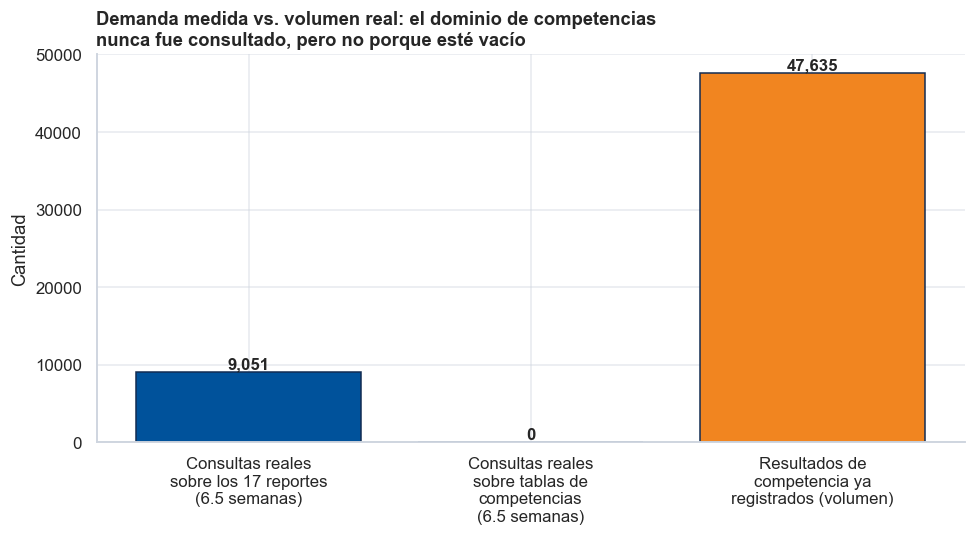


Participaciones registradas (deportista x disciplina): 732,640


In [22]:
volumen_reportes = int(tabla_maestra["frecuencia_datos"].sum())
volumen_competencias = mapeo_competencias["conteos_reales"]["bronze_suid_events.result_entries"]
participaciones = mapeo_competencias["conteos_reales"]["bronze_suid_events.participant_disciplines"]

fig, ax = plt.subplots(figsize=(9, 5))
categorias = ["Consultas reales\nsobre los 17 reportes\n(6.5 semanas)",
              "Consultas reales\nsobre tablas de\ncompetencias\n(6.5 semanas)",
              "Resultados de\ncompetencia ya\nregistrados (volumen)"]
valores = [volumen_reportes, 0, volumen_competencias]
colores = [AZUL, GRIS_BORDE, NARANJA]
barras = ax.bar(categorias, valores, color=colores, edgecolor=AZUL_OSC)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:,}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_title("Demanda medida vs. volumen real: el dominio de competencias\n"
             "nunca fue consultado, pero no porque esté vacío", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_hallazgo_competencias.png", bbox_inches="tight")
plt.show()

print(f"\nParticipaciones registradas (deportista x disciplina): {participaciones:,}")


**Lectura.** El volumen de datos real del dominio de competencias
(47.635 resultados de competencia, 732.640 participaciones deportista×
disciplina) es varias veces mayor que el volumen procesado por cualquiera
de los 17 reportes actuales — pero su barra de consultas históricas es
literalmente cero. Esto descarta la explicación de "es un dominio
pequeño, por eso nadie lo consulta": es un dominio grande, simplemente sin
ningún punto de entrada hoy.

### 19.1 El caso de uso que motivó la investigación

El objetivo explícito era validar si el buscador podría resolver una
consulta como **"Atletismo Pre-Juvenil en Región Caribe 1"**. La
investigación confirmó que esta frase **no corresponde a ningún campo
existente**: es la combinación de tres conceptos reales, verificados
contra datos reales (no inventados), que hoy viven en tres tablas
distintas.

In [23]:
ejemplo = mapeo_competencias["ejemplo_busqueda_objetivo"]
print("Consulta objetivo:", ejemplo["consulta_usuario"])
print("¿Es un campo existente?:", ejemplo["es_un_campo_existente"])
print()
for comp in ejemplo["componentes"]:
    print(f"- {comp['concepto']}: {comp['valor_real']}  (fuente: {comp['fuente']})")
print()
print("Entidad sintética propuesta:", ejemplo["entidad_sintetica_propuesta"])
print(ejemplo["definicion"])


Consulta objetivo: Atletismo Pre-Juvenil en Región Caribe 1
¿Es un campo existente?: False

- deporte + categoria: Atletismo / Pre Juvenil  (fuente: bronze_suid_events.disciplines.sport_name / category_name)
- region: Caribe 1  (fuente: gold_suid.region_progress.region_name)
- fase: Regionales  (fuente: bronze_suid_events.phases.name)

Entidad sintética propuesta: Competencia / Prueba Regional
Interseccion de una disciplina (deporte+categoria), una fase (Regionales) y una region -- no materializada en ninguna tabla hoy, igual que el hallazgo original del Reporte de Promocion en el EDA de reportes.


Este es exactamente el mismo patrón que ya se había encontrado con
el "Reporte de Promoción de Deportistas" (Sección 14): una pregunta de
negocio real, sin tabla dedicada que la resuelva, reconstruida mediante
`JOIN`s entre tablas base. La diferencia es que esta vez el patrón aparece
en un dominio —competencias— que ni siquiera tiene un reporte que lo
intente resolver hoy.

**Recomendación resultante.** Este hallazgo se documenta en detalle en
`data/competencias_suid/README.md` y en `mapeo_competencias.json` (mismo
archivo cargado arriba), e impulsó una extensión de la ontología del
buscador (`Exploracion_Ontologia_Metadatos_SUID.ipynb`, Sección 11) con
una nueva entidad **Competencia / Prueba Regional** y una entidad
**Región**. Para la siguiente fase del proyecto, el dominio de
competencias es un candidato con mejor caso de negocio para el buscador
semántico que profundizar aún más en los 17 reportes ya cubiertos por
este documento.

### 19.2 Mapeo diferencial: los 17 reportes frente al dominio de competencias

Las secciones anteriores midieron dos dominios con reglas distintas, así que conviene
compararlos de frente. La tabla y la figura siguientes ponen lado a lado la demanda
observada y el tamaño real de cada dominio, y separan qué entidades son transversales
(aparecen en ambos) de las que son propias de cada uno. El objetivo es dejar explícito
por qué la baja demanda de competencias no es evidencia de poca relevancia.

Entidades transversales (en ambos dominios): Deportista, Disciplina Deportiva, Etapa/Fase, Evento, Grupo, Institución
Entidades propias de competencias: Competencia / Prueba Regional, Región (deportiva)


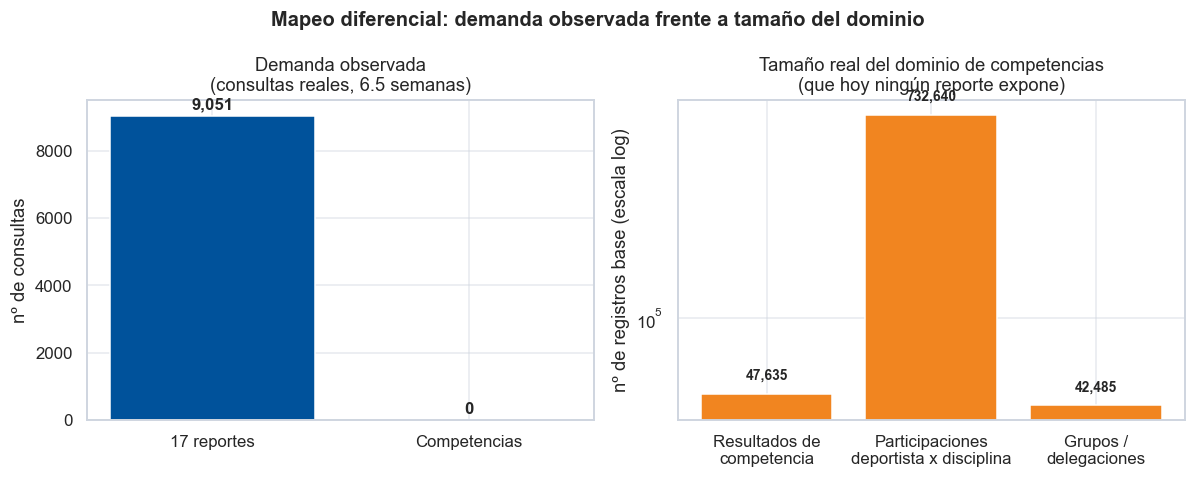

,Dimensión,17 reportes,Competencias
0,Consultas reales (6.5 semanas),"9,051",0
1,¿Expuesto por algún reporte gold?,Sí (17),No (capa silver vacía)
2,Concentración / tamaño,top-5 = 86% de la demanda,"47,635 resultados; 732,640 participaciones"
3,Entidad central,Reporte Individual de Deportistas,Prueba Regional (sintética)
4,Cómo se arma la pregunta clave,JOIN al vuelo (Promoción),JOIN al vuelo (disciplina x fase x región)
5,Estado en el buscador,v1,v2 (prioridad)


In [24]:
# --- Mapeo diferencial: 17 reportes vs dominio de competencias ---
import csv, json
from pathlib import Path

BASE = Path("..") / "data"

# 1) Demanda y concentración de los 17 reportes
filas = list(csv.DictReader(open(BASE / "athena_suid" / "tabla_maestra_reportes.csv",
                                 encoding="utf-8")))
frec = [int(r["Frecuencia de consultas de datos"]) for r in filas]
demanda_total = sum(frec)
pct_top5 = 100 * sum(sorted(frec, reverse=True)[:5]) / demanda_total

# 2) Volumen real del dominio de competencias
conteos = json.load(open(BASE / "competencias_suid" / "conteos.json",
                         encoding="utf-8"))["conteos"]
result_entries = conteos["bronze_suid_events.result_entries"]
participaciones = conteos["bronze_suid_events.participant_disciplines"]
grupos = conteos["bronze_suid_events.groups"]

# 3) Entidades transversales vs propias de cada dominio
meta = json.load(open(BASE / "ontologia_suid" / "metadatos_por_reporte.json",
                      encoding="utf-8"))
ent_reportes = set()
for e in meta:
    ent_reportes.update(e["entidades_principales"])
ent_competencias = {"Competencia / Prueba Regional", "Disciplina Deportiva",
                    "Región (deportiva)", "Etapa/Fase", "Evento",
                    "Deportista", "Grupo", "Institución"}
transversales = sorted(ent_reportes & ent_competencias)
solo_competencias = sorted(ent_competencias - ent_reportes)
print("Entidades transversales (en ambos dominios):", ", ".join(transversales))
print("Entidades propias de competencias:", ", ".join(solo_competencias))

# 4) Tabla comparativa
tabla_dif = pd.DataFrame([
    {"Dimensión": "Consultas reales (6.5 semanas)",
     "17 reportes": f"{demanda_total:,}", "Competencias": "0"},
    {"Dimensión": "¿Expuesto por algún reporte gold?",
     "17 reportes": "Sí (17)", "Competencias": "No (capa silver vacía)"},
    {"Dimensión": "Concentración / tamaño",
     "17 reportes": f"top-5 = {pct_top5:.0f}% de la demanda",
     "Competencias": f"{result_entries:,} resultados; {participaciones:,} participaciones"},
    {"Dimensión": "Entidad central",
     "17 reportes": "Reporte Individual de Deportistas",
     "Competencias": "Prueba Regional (sintética)"},
    {"Dimensión": "Cómo se arma la pregunta clave",
     "17 reportes": "JOIN al vuelo (Promoción)",
     "Competencias": "JOIN al vuelo (disciplina x fase x región)"},
    {"Dimensión": "Estado en el buscador",
     "17 reportes": "v1", "Competencias": "v2 (prioridad)"},
])

# 5) Figura de dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.bar(["17 reportes", "Competencias"], [demanda_total, 0], color=[AZUL, NARANJA])
ax1.set_title("Demanda observada\n(consultas reales, 6.5 semanas)")
ax1.set_ylabel("nº de consultas")
for i, v in enumerate([demanda_total, 0]):
    ax1.text(i, v + demanda_total * 0.02, f"{v:,}", ha="center", fontweight="bold")

etiquetas = ["Resultados de\ncompetencia", "Participaciones\ndeportista x disciplina",
             "Grupos /\ndelegaciones"]
valores = [result_entries, participaciones, grupos]
ax2.bar(etiquetas, valores, color=NARANJA)
ax2.set_title("Tamaño real del dominio de competencias\n(que hoy ningún reporte expone)")
ax2.set_ylabel("nº de registros base (escala log)")
ax2.set_yscale("log")
for i, v in enumerate(valores):
    ax2.text(i, v * 1.15, f"{v:,}", ha="center", fontweight="bold", fontsize=9)

fig.suptitle("Mapeo diferencial: demanda observada frente a tamaño del dominio",
             fontweight="bold")
fig.tight_layout()
fig.savefig(BASE / "athena_suid" / "fig_diferencial_dominios.png",
            dpi=150, bbox_inches="tight")
plt.show()
tabla_dif

**Lectura.** Los dos dominios ocupan esquinas opuestas. Los 17 reportes concentran
toda la demanda observada, pero ya los resuelve un tablero estructurado; el dominio de
competencias no registra ni una consulta porque ningún reporte lo expone, aunque su
volumen real es mucho mayor. Las entidades transversales (deportista, institución,
evento, disciplina, etapa) confirman que un mismo buscador cubre ambos dominios sin
rehacer la ontología; lo propio de competencias es la Región deportiva y la Prueba
Regional. En los dos dominios reaparece el mismo patrón: una pregunta de negocio real
que hoy se arma con un JOIN al vuelo y que no tiene tabla dedicada, la Promoción en los
reportes y la Prueba Regional en competencias.

## 20. Alcance de la versión 1 del buscador semántico

Con todo lo anterior, el alcance de la primera versión queda acotado y defendible.

**Qué entra en la v1.** La v1 se construye sobre los 17 reportes ya mapeados y la
ontología ya definida. Su corpus son las descripciones en lenguaje natural de la
sección 15, enriquecidas con el bloque de metadatos de la ontología (entidades,
sinónimos, preguntas de negocio), en el formato que produce el módulo de
preprocesamiento del proyecto. Los cinco reportes de prioridad Alta, que concentran el
86% de la demanda real, son el punto de partida.

**Qué queda para la v2.** El dominio de competencias (eventos, fases, disciplinas,
resultados) es la extensión prioritaria de la v2. La razón no es la demanda medida, que
es cero, sino que ese cero es un vacío de cobertura: un dominio grande (47.635
resultados de competencia) que hoy ningún reporte expone. La entidad Prueba Regional ya
está modelada en la ontología con su fórmula de construcción, así que la v2 reutiliza la
misma tubería sin rediseñarla.

**Separación de privacidad, en las dos versiones.** El corpus semántico no contiene
datos personales. La búsqueda por nombre propio de una persona o institución se resuelve
en un componente aparte, con control de acceso, coherente con que los nombres de
participante ya viajan cifrados a nivel de columna en la capa base.

## 21. Conclusiones

1. La demanda de reportes del sistema deportivo está muy concentrada: un
   grupo pequeño de reportes —encabezado, con amplio margen, por el
   **Reporte de Promoción de Deportistas**— explica la mayor parte de las
   solicitudes reales observadas.
2. Aproximadamente la mitad de lo que el sistema registra como
   "solicitudes" son en realidad verificaciones internas de paginación, no
   peticiones nuevas de un usuario. Ignorar esta distinción habría inflado
   artificialmente la demanda medida.
3. El reporte más solicitado se recalcula por completo cada vez que se
   pide, porque su resultado depende de una lógica de negocio que combina
   varias fuentes de datos y que hoy no está guardada en ningún lugar ya
   resuelta. Se propuso, en lenguaje natural, cómo debería verse esa fuente
   de datos si se decidiera crearla.
4. Existe una fuente de datos claramente central en el sistema —el
   **Reporte Individual de Deportistas**—, que se combina con la mayoría de
   las demás y que debería tratarse como punto de partida al diseñar cómo
   se organiza el contenido del buscador.
5. Se generaron automáticamente descripciones en lenguaje natural para cada
   reporte, listas para ser el contenido de partida que el buscador
   semántico compare contra las preguntas de un usuario.
6. De las cuatro ideas metodológicas del sistema de Uber Eats revisado en
   la monografía, solo dos son parcialmente adoptables aquí (el ajuste de
   tamaño del modelo, y la idea de un juez automático para validación); las
   otras dos —el volumen masivo de datos de entrenamiento y la
   infraestructura de entrenamiento a gran escala— quedan fuera del alcance
   de este proyecto, por decisión explícita y no por descuido.
7. **Los 17 reportes analizados no son todo el sistema.** El dominio de
   **competencias** (eventos, fases, disciplinas, resultados) tiene un
   volumen real varias veces mayor que cualquier reporte aquí analizado, y
   registra **cero consultas** en el mismo historial de Athena —no por
   baja demanda, sino porque nunca se expuso como reporte (Sección 19).
   Es, en la práctica, un candidato con mejor caso de negocio para las
   siguientes fases del buscador semántico que seguir profundizando en los
   reportes ya cubiertos por este documento.

## 22. Limitaciones

- La ventana de datos disponible (~6.5 semanas) es un límite impuesto por
  la plataforma de consultas, no una elección de este análisis. Si en el
  futuro fuera posible recuperar de 6 a 12 meses de historial, una
  hipótesis razonable —pero **no verificada aquí**— es que el orden de los
  5 reportes más solicitados se mantendría, dado lo marcado de la
  concentración observada; esto debería confirmarse cuando esa ventana más
  amplia esté disponible.
- La clasificación automática de reportes, aunque ahora se apoya en un
  analizador estructural real, sigue basándose en reglas escritas
  manualmente. La Sección 16 dejó preparada, pero no ejecutada, la
  verificación formal de qué tan precisas son esas reglas.
- Este análisis describe **cuántas veces se pidió cada reporte**, no si el
  resultado que recibió el usuario fue útil o correcto.
- No se tiene información de quién solicitó cada reporte (esa información
  no queda registrada en el sistema de consultas usado para este análisis).

## 23. Referencias

- Ling, B., Liu, Z., Chen, H., Nagar, D., Yang, L. y Parsana, M. (2026).
  *Scaling Multilingual Semantic Search in Uber Eats Delivery*. arXiv
  preprint arXiv:2603.06586.
- Peñaranda Pérez, L. D. (2026). *Escalando la búsqueda semántica en
  plataformas GovTech* [Monografía de grado, Universidad del Norte].
- Documentación interna: `data/athena_suid/README.md`.
- Documentación interna: `data/competencias_suid/README.md` y
  `mapeo_competencias.json` (hallazgo de la Sección 19).
